In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

import experiment_utils
from main import *
import plotstyle
plotstyle.set_plot_style()

In [249]:
import train_dt_clip
argd = train_dt_clip.Args()

argd.n_iters = 100000
argd.log_every = 10000

args_all = []
seeds_all = range(1)
dts_all = [1, 2, 4, 8, 16, 32, 64, 128]
gol_params_all = [6152, 7291, 7787, 15923]
# gol_params_all = [6152, 242251, 7291, 7787, 55871, 15923]
# gol_params_all = [2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
# gol_params_all = [6152, 242251, 7291, 7787, 55871, 15923, 2579, 5691, 47999, 55615, 56127, 8059, 55903, 133519, 55359, 3731, 36703, 34335]
layers_all = [2, 4, 8, 16]
for seed in seeds_all:
    for gol_params in gol_params_all:
        for dt in dts_all:
            for layers in layers_all:
                args = copy.deepcopy(argd)
                args.data.gol_params = gol_params
                args.seed = seed
                args.data.dt = dt
                args.model.layers = layers
                args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/run_8/gol_params={gol_params}_dt={dt}_layers={layers}_seed={seed}"
                args_all.append(args)
                # print(args)
print(len(args_all))
experiment_utils.create_commands(args_all, prefix="python train_dt_clip.py", out_file="science_scripts/main.sh");

128


In [250]:
# import linear_probe
# argd = linear_probe.LinearProbeArgs()

# argd.n_iters = 1000

# lp_args_all = []
# for args in args_all:
#     for ablate_features in ["none", "random"]:
#         for target in ["x0", "x1"]:
#             lp_args = copy.deepcopy(argd)
#             lp_args.seed = args.seed
#             lp_args.load_dir = args.save_dir
#             lp_args.save_dir = f"{args.save_dir}_lp_{ablate_features}_{target}"
#             lp_args.ablate_features = ablate_features
#             lp_args.target = target
#             lp_args_all.append(lp_args)
#             # print(lp_args)
# print(len(lp_args_all))
# experiment_utils.create_commands(lp_args_all, prefix="python linear_probe.py", out_file="science_scripts/linear_probe.sh");

In [254]:
from train_dt_clip import Main, Args

from foundation_models.clip import CLIP

clip = CLIP()

def generate_instance(self, rng):
    rng, _rng = split(rng)
    state = self.rollout_fn(_rng, self.args.data.gol_params)['state']

    rng, _rng = split(rng)
    t0 = jax.random.randint(_rng, shape=(), minval=self.args.data.t_start, maxval=self.args.data.t_end-2)

    rng, _rng = split(rng)
    dt_id = jax.random.randint(_rng, shape=(), minval=0, maxval=len(self.dts))
    dt = self.dts[dt_id]
    t1 = t0 + dt
    # state = state[t0:t0+128]
    # state = state[jnp.arange(t0, t1, 1)]
    state = jax.lax.dynamic_slice(state, (t0, 0, 0), (128+1, 64, 64))
    def scan_fn(_, x):
        img = self.substrate.render_state(x, self.args.data.gol_params, img_size=224)
        z = clip.embed_img(img)
        return _, z
    _, z = jax.lax.scan(scan_fn, None, state)
    return z
    
gol_params2batch = {}
for gol_params in gol_params_all:
    a = Args()
    a.data.gol_params = gol_params
    a.data.dt = 128
    a.opt.batch_size = 256
    # a.opt.batch_size = 16
    m = Main(a)
    # m.init()
    rng = jax.random.PRNGKey(0)
    # batch = generate_instance(m, rng)
    batch = jax.vmap(partial(generate_instance, m))(split(rng, a.opt.batch_size))
    gol_params2batch[gol_params] = batch

Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=8), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[128]))
Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=8), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[128]))
Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=8), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=7787, grid_size=64, t_start=32, t_end=64, dt=[128]))
Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=8), opt=OptimizerArgs(batch_size=256, lea

In [ ]:
args = args_all[28]
main = Main(args)
main.init()

rng = jax.random.PRNGKey(0)
batch = main.generate_batch(rng)
batch['x_clip'].shape

params = util.load_pkl(args.save_dir, "params")
loss, _ = main.loss_fn(params, batch)

In [ ]:
print(loss)

In [305]:
def calc_rollout_accuracy(main, params, batch):
    args = main.args
    dt_total = 128
    dt = args.data.dt[0]
    assert dt_total % dt == 0
    n_steps = dt_total // dt
    # print(dt_total, dt, n_steps)

    # x, y = batch['x_clip'], batch['y_clip']
    z = batch # (B, T, D)

    def step(x, _):
        loss, outputs = jax.vmap(main.net.apply, in_axes=(None, 0, 0))(params, x, x) # (B, H, W, 2)
        pred = outputs['y_pred']
        return pred, pred
    y_pred, trajectory = jax.lax.scan(step, z[:, 0, :], None, length=n_steps)
    z = z[:, dt::dt]
    trajectory = rearrange(trajectory, "T B D -> B T D")
    loss = ((z-trajectory)**2).mean(axis=(0, 2))
    return loss

In [306]:
rollout_losses = []
for args in tqdm(args_all):
    main = Main(args)
    params = util.load_pkl(args.save_dir, "params")
    loss = calc_rollout_accuracy(main, params, gol_params2batch[args.data.gol_params])
    rollout_losses.append(loss)

 98%|█████████▊| 125/128 [02:11<00:03,  1.02s/it]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_8/gol_params=15923_dt=128_layers=4_seed=0', n_iters=100000, log_every=10000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=4), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=15923, grid_size=64, t_start=32, t_end=64, dt=[128]))


 98%|█████████▊| 126/128 [02:12<00:01,  1.01it/s]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_8/gol_params=15923_dt=128_layers=8_seed=0', n_iters=100000, log_every=10000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=8), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=15923, grid_size=64, t_start=32, t_end=64, dt=[128]))


 99%|█████████▉| 127/128 [02:13<00:01,  1.01s/it]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_8/gol_params=15923_dt=128_layers=16_seed=0', n_iters=100000, log_every=10000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=16), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=15923, grid_size=64, t_start=32, t_end=64, dt=[128]))


100%|██████████| 128/128 [02:15<00:00,  1.06s/it]


In [325]:
gol_params2random_loss = {}
for gol_params in gol_params_all:
    z = gol_params2batch[gol_params][:, 64]
    baseline = z.mean(axis=0)
    random = ((z - baseline)**2).mean()
    gol_params2random_loss[gol_params] = random.item()

print(gol_params2random_loss)

{6152: 5.988188786432147e-05, 7291: 8.983331645140424e-05, 7787: 0.0001641583803575486, 15923: 0.00011587749031605199}


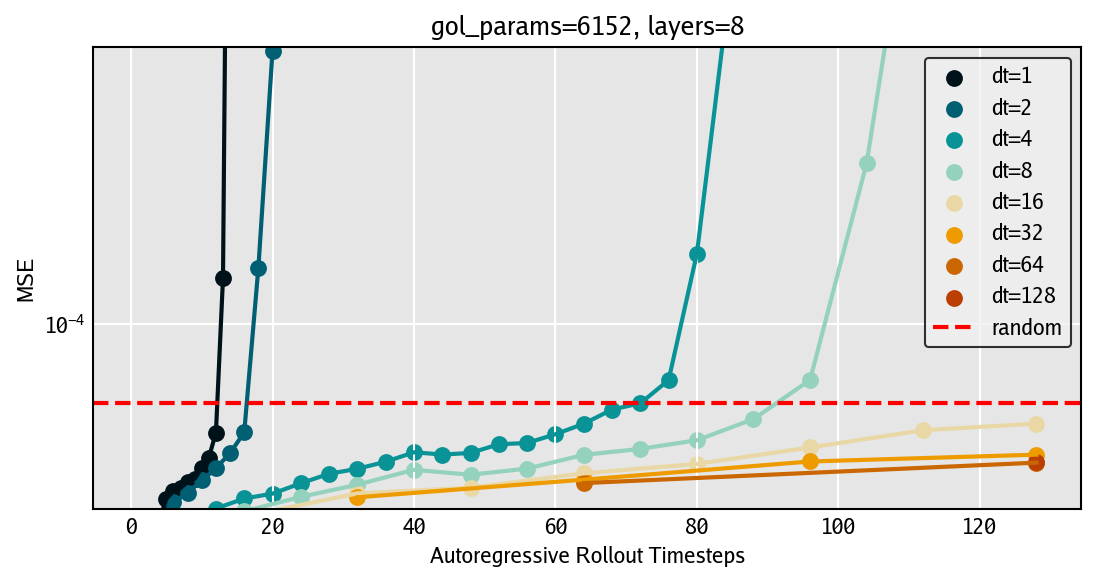

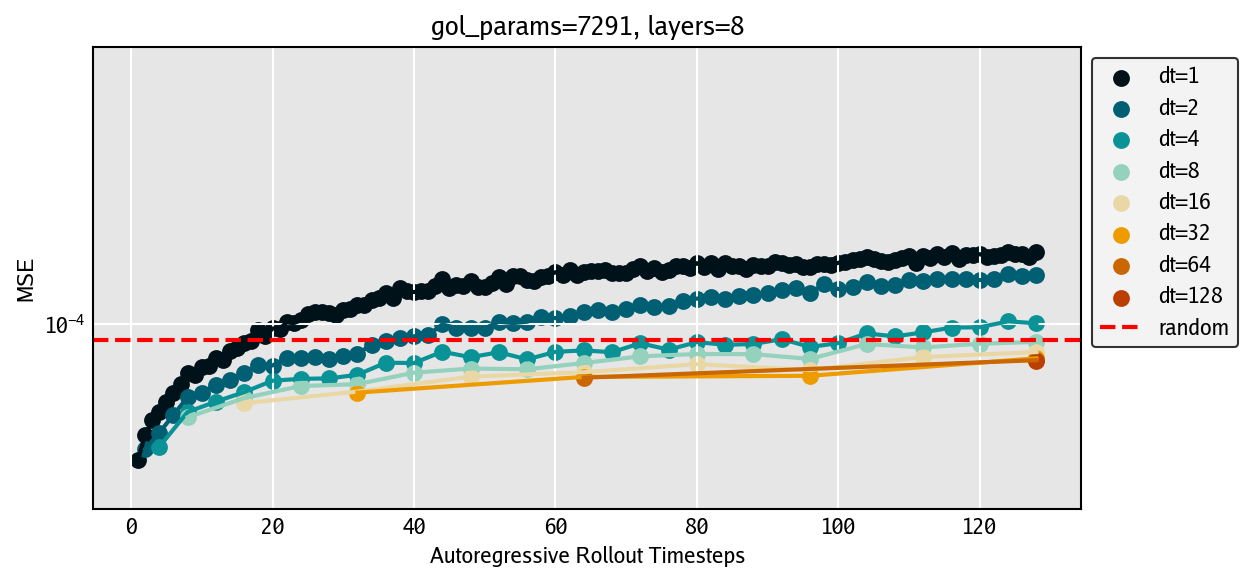

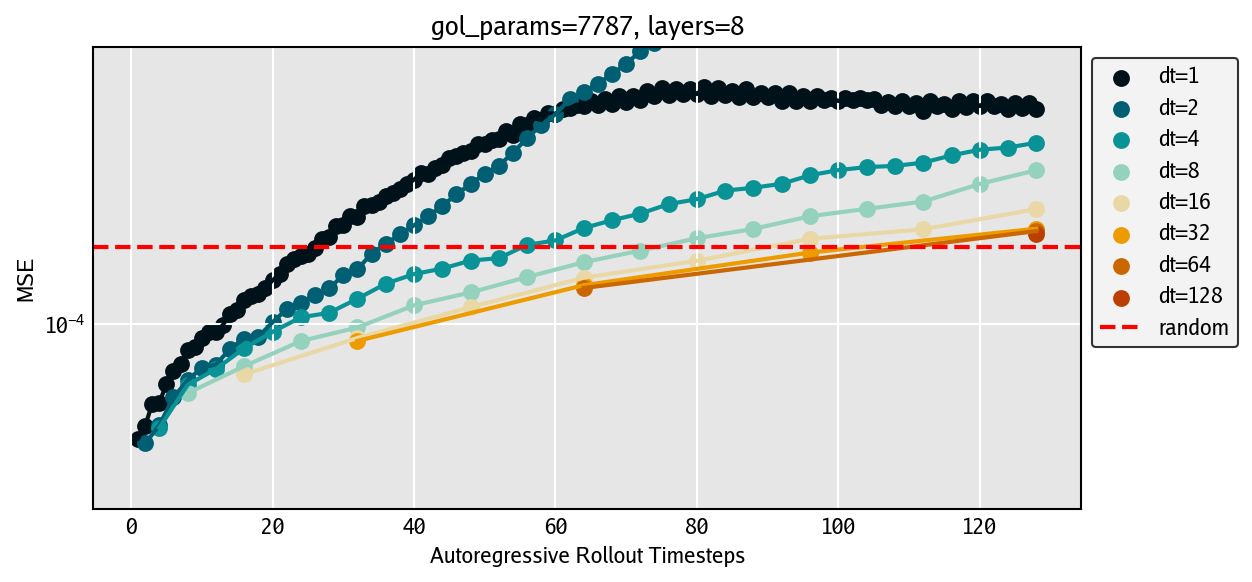

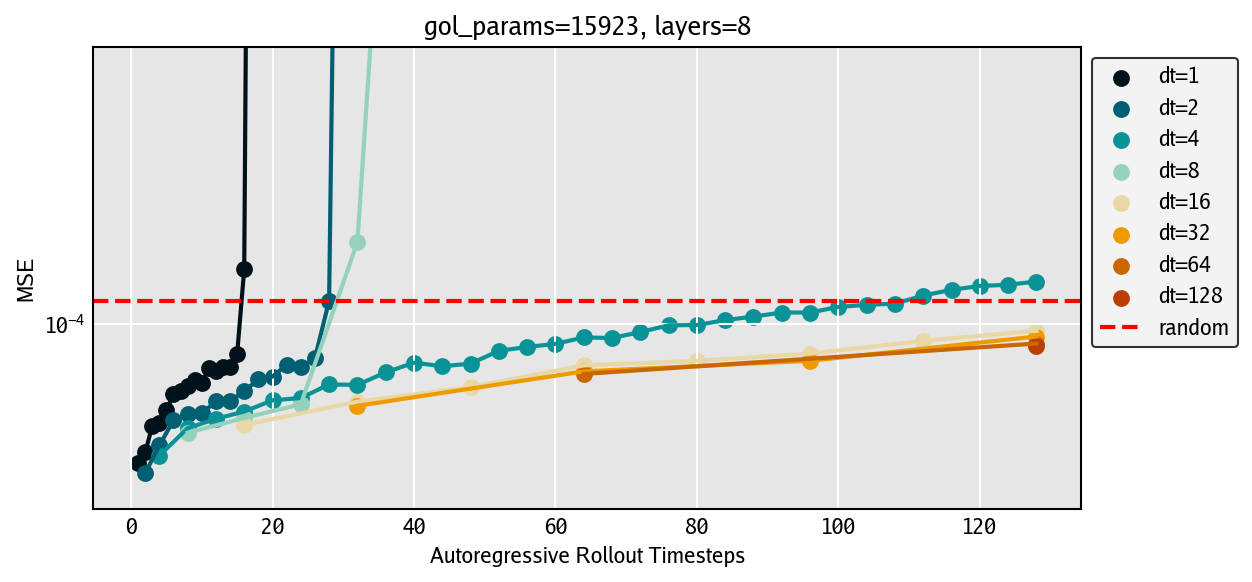

In [345]:
layers = 8
for gol_params in gol_params_all:
    for i, args in enumerate(args_all):
        if args.data.gol_params != gol_params or args.model.layers != layers:
            continue
        args = args_all[i]
        dt = args.data.dt
        loss = rollout_losses[i]
        plt.plot(np.arange(dt, 128+1, dt), loss)
        plt.scatter(np.arange(dt, 128+1, dt), loss, s=50, label=f'dt={dt}')

    plt.axhline(gol_params2random_loss[gol_params], color='red', linestyle='--', label='random')

    plt.yscale('log')
    plt.ylim(3e-5, 6e-4)
    # plt.ylim(1e-4, 3e-4)
    plt.legend(bbox_to_anchor=(1, 1))

    plt.title(f'gol_params={gol_params}, layers={layers}')
    plt.xlabel("Autoregressive Rollout Timesteps")
    plt.ylabel("MSE")
    plt.show()

In [350]:
df = []
for i, args in enumerate(args_all):
    final_loss = util.load_pkl(args.save_dir, "final_loss")
    rollout_loss = rollout_losses[i][-1].item()
    flops = args.model.layers * 128//args.data.dt
    dfi = dict(seed=args.seed, dt=args.data.dt, layers=args.model.layers, gol_params=args.data.gol_params, final_loss=final_loss, rollout_loss=rollout_loss, flops=flops)
    df.append(dfi)
df = pd.DataFrame(df)

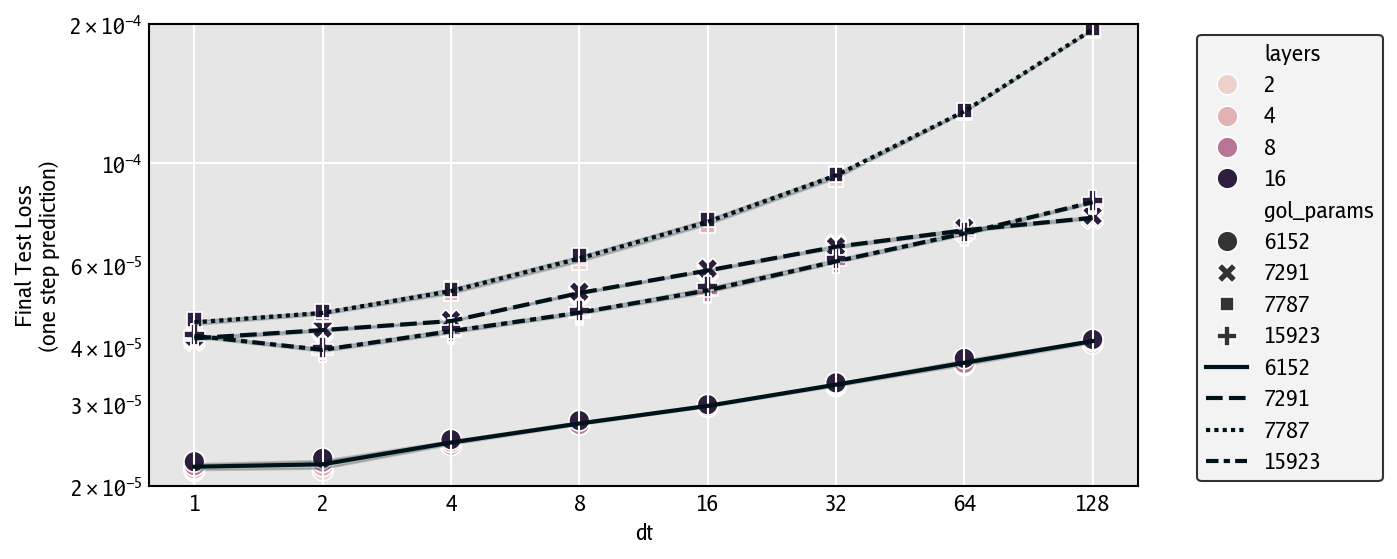

In [353]:
sns.scatterplot(data=df, x='dt', y='final_loss', hue='layers', style='gol_params', s=100)
sns.lineplot(data=df, x='dt', y='final_loss', style='gol_params')
plt.xscale('log')
plt.ylim(2e-5, 20e-5)
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(dts_all, dts_all);
plt.ylabel("Final Test Loss\n(one step prediction)")
plt.xlabel("dt")
plt.show()

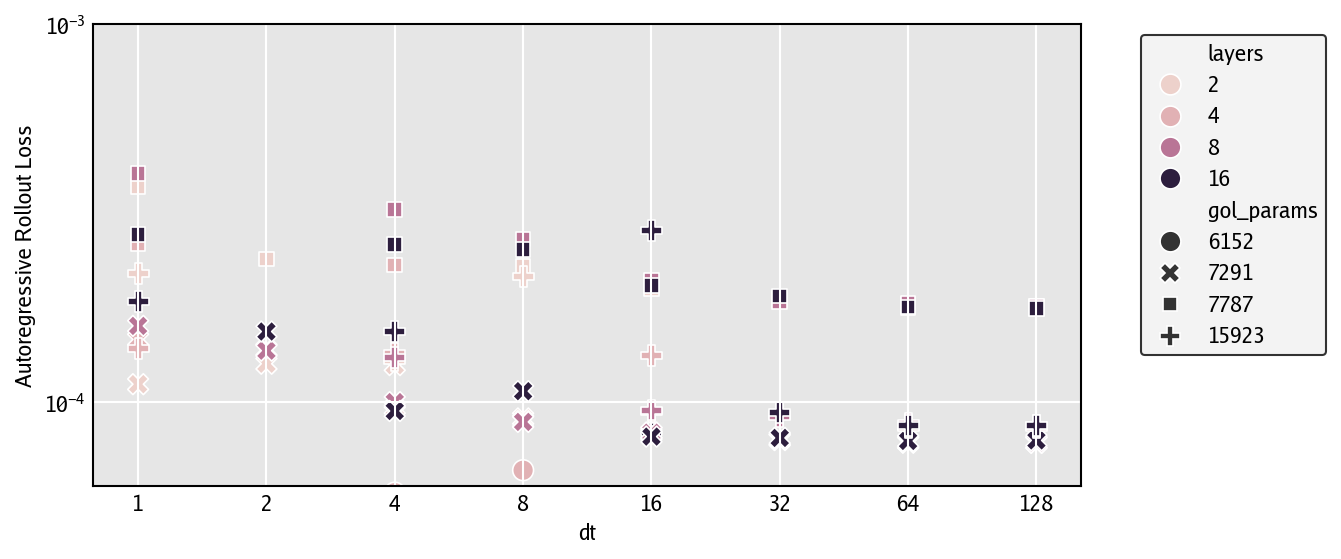

In [374]:
sns.scatterplot(data=df, x='dt', y='rollout_loss', hue='layers', style='gol_params', s=100)
# sns.lineplot(data=df, x='dt', y='rollout_loss', style='gol_params')
plt.xscale('log')
plt.ylim(6e-5, 100e-5)
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(dts_all, dts_all);
plt.ylabel("Autoregressive Rollout Loss")
plt.xlabel("dt")
# plt.yticks(np.arange(6e-5, 100e-5, 10e-5), [f"{x:.1e}" for x in np.arange(6e-5, 100e-5, 10e-5)])
plt.show()

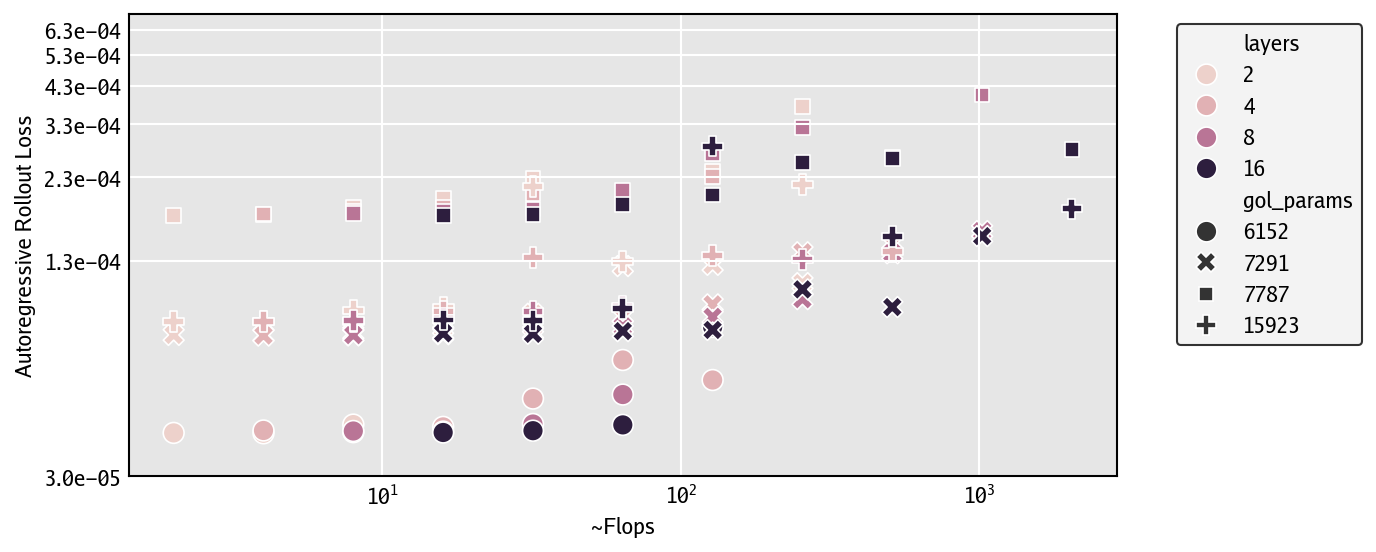

In [375]:
sns.scatterplot(data=df, x='flops', y='rollout_loss', hue='layers', style='gol_params', s=100)
# sns.scatterplot(data=df, x='flops', y='rollout_loss', style='gol_params', s=100)
plt.yscale('log')
plt.xscale('log')
plt.ylim(3e-5, 70e-5)
plt.yticks(np.arange(3e-5, 70e-5, 10e-5), [f"{x:.1e}" for x in np.arange(3e-5, 70e-5, 10e-5)])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.ylabel("Autoregressive Rollout Loss")
plt.xlabel("~Flops")

plt.show()

In [69]:
for args in args_all:
    main = Main(args)

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_8/gol_params=6152_dt=1_layers=2_seed=0', n_iters=100000, log_every=10000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=2), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[1]))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_8/gol_params=6152_dt=1_layers=4_seed=0', n_iters=100000, log_every=10000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=4), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[1]))
Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_8/gol_params=6152_dt=1_layers=8_seed=0', n_iters=100000, log_every=10000, model=DTCLIPNetworkConfig(d_hidden=1024, layers=8), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_n

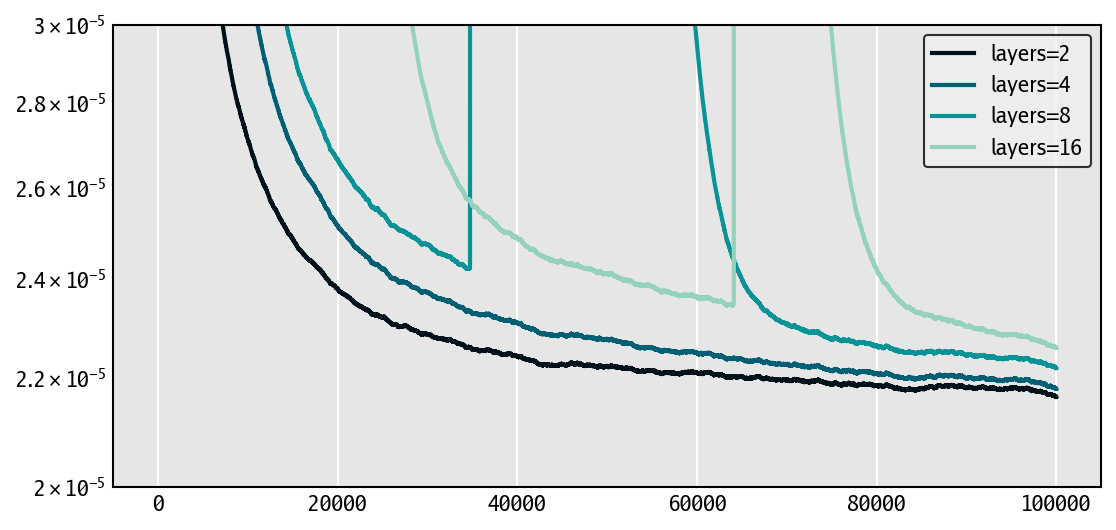

In [51]:
for args in args_all[0:4]:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    plt.plot(pd.DataFrame(loss_history).ewm(span=5000).mean(), label=f"layers={args.model.layers}")
plt.yscale('log')
plt.ylim(2e-5, 3e-5)
plt.legend()
plt.show()

In [5]:
from main import Main, Args

gol_params2batch = {}
for gol_params in gol_params_all:
    a = Args()
    a.data.gol_params = gol_params
    a.data.dt = 128
    a.opt.batch_size = 1024
    m = Main(a)
    rng = jax.random.PRNGKey(0)
    batch = m.generate_batch(rng)
    gol_params2batch[gol_params] = batch

def calc_rollout_accuracy(main, params, batch):
    args = main.args
    dt_total = batch['dt'][0]
    dt = args.data.dt[0]
    assert dt_total % dt == 0
    n_steps = dt_total // dt

    x0, x1, dt_id = batch['x0'], batch['x1'], batch['dt_id']
    def step(x0, _):
        logits = jax.vmap(main.net.apply, in_axes=(None, 0, 0))(params, x0, dt_id) # (B, H, W, 2)
        x1 = jnp.argmax(logits, axis=-1)
        return x1, None
    x1_pred, _ = jax.lax.scan(step, x0, None, length=n_steps)

    accuracy = (x1 == x1_pred).mean().item()
    return accuracy

Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=1024, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64, dt=[128]))


Could not load symbol cuFuncGetName. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=1024, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[128]))
Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=1024, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7787, grid_size=64, t_start=32, t_end=64, dt=[128]))
Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=1024, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=15923, grid_size=64, t_start=32, t_end=64, dt=[128]))


In [ ]:
df = []
for i, args in enumerate(tqdm(args_all)):
    layers = args.model.layers
    dt = args.data.dt
    total_flops = (128 // dt) * layers
    final_loss = util.load_pkl(args.save_dir, "final_loss")

    metrics_x0 = util.load_pkl(f"{args.save_dir}_lp_none_x0", "metrics")
    metrics_x1 = util.load_pkl(f"{args.save_dir}_lp_none_x1", "metrics")
    metrics_rand_x0 = util.load_pkl(f"{args.save_dir}_lp_random_x0", "metrics")
    metrics_rand_x1 = util.load_pkl(f"{args.save_dir}_lp_random_x1", "metrics")


    params = util.load_pkl(args.save_dir, "params")
    main = Main(copy.deepcopy(args))
    rollout_accuracy = calc_rollout_accuracy(main, params, gol_params2batch[args.data.gol_params])

    dfi = dict(gol_params=str(args.data.gol_params), layers=layers, dt=str(dt), total_flops=total_flops,
               final_loss=final_loss, rollout_accuracy=rollout_accuracy,
               score_x0=metrics_x0['score_test'], score_x1=metrics_x1['score_test'],
               score_rand_x0=metrics_rand_x0['score_test'], score_rand_x1=metrics_rand_x1['score_test'])
    df.append(dfi)
df = pd.DataFrame(df)
df

In [7]:
df

,gol_params,layers,dt,total_flops,final_loss,rollout_accuracy,score_x0,score_x1,score_rand_x0,score_rand_x1
0,6152,2,1,256,-0.000000e+00,1.000000,0.276049,0.274833,0.301916,0.288383
1,6152,4,1,512,-0.000000e+00,1.000000,0.270883,0.270772,0.309606,0.295426
2,6152,8,1,1024,4.547473e-14,1.000000,0.281220,0.278497,0.317939,0.304639
3,6152,16,1,2048,1.618271e-09,1.000000,0.284303,0.279601,0.328296,0.315427
4,6152,2,2,128,9.094946e-15,1.000000,0.266273,0.266540,0.301916,0.284859
...,...,...,...,...,...,...,...,...,...,...
123,15923,16,64,32,5.156121e-01,0.719247,0.448022,0.329180,0.393708,0.290121
124,15923,2,128,2,5.605208e-01,0.696682,0.427506,0.262544,0.373215,0.239781
125,15923,4,128,4,5.394350e-01,0.715544,0.446304,0.273944,0.380847,0.241819
126,15923,8,128,8,5.323903e-01,0.721643,0.451856,0.281453,0.385633,0.244903


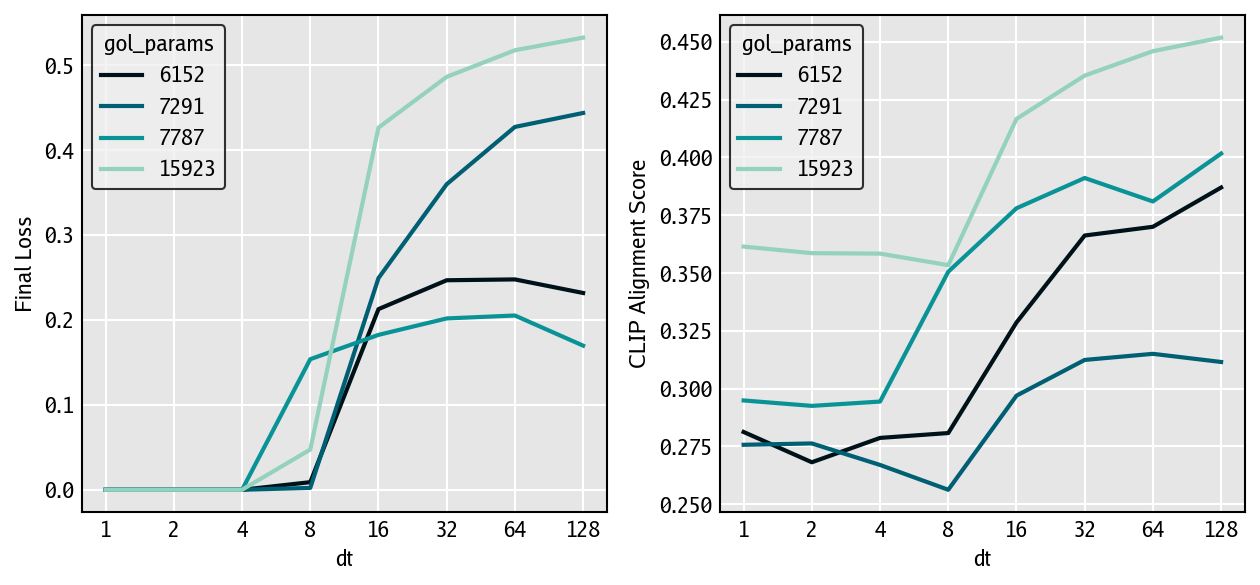

In [52]:
plt.subplot(121)
sns.lineplot(data=df[df.layers==8], x="dt", y="final_loss", hue='gol_params')
plt.ylabel("Final Loss"); plt.xlabel("dt")
plt.subplot(122)
sns.lineplot(data=df[df.layers==8], x="dt", y="score_x0", hue='gol_params')
plt.ylabel("CLIP Alignment Score"); plt.xlabel("dt")
plt.tight_layout()
plt.show()

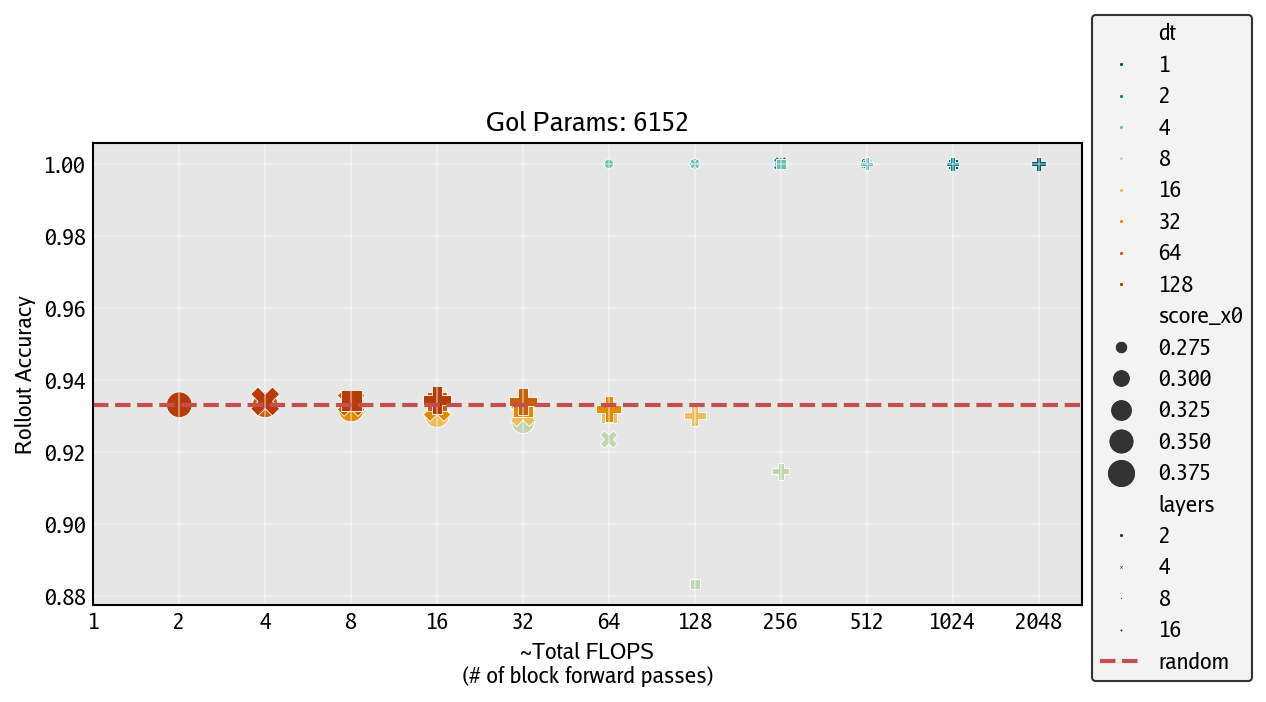

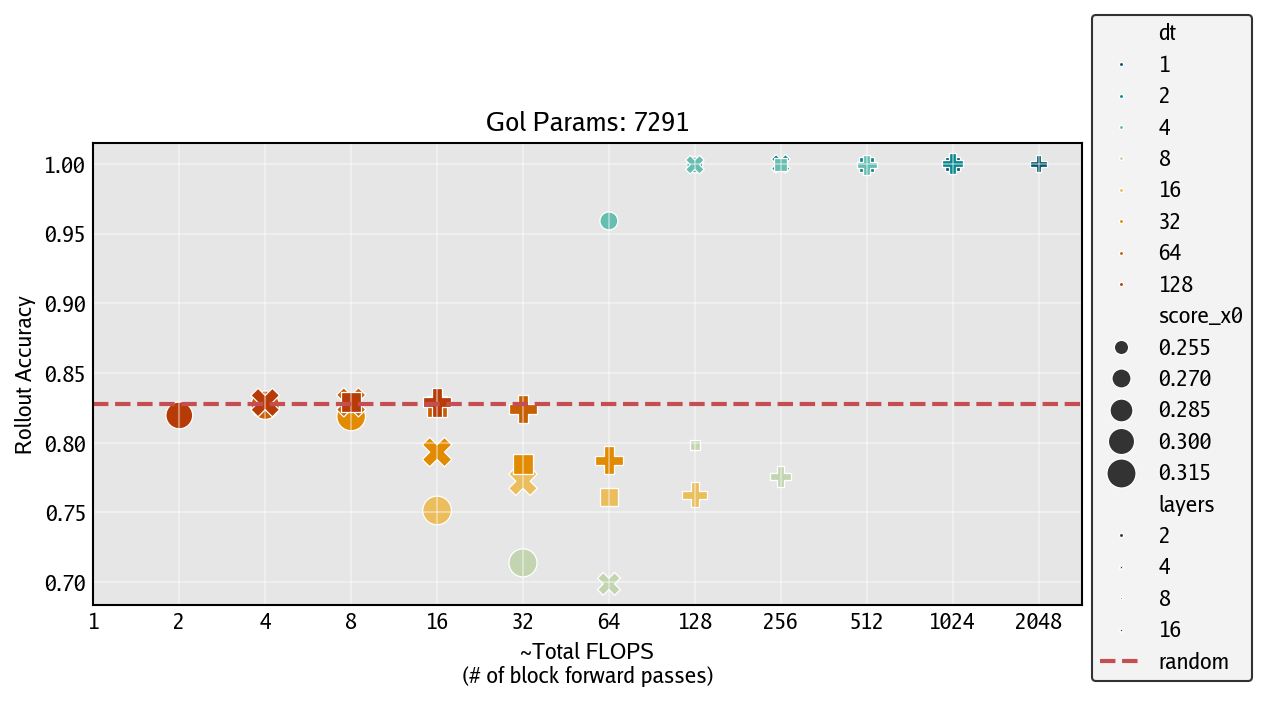

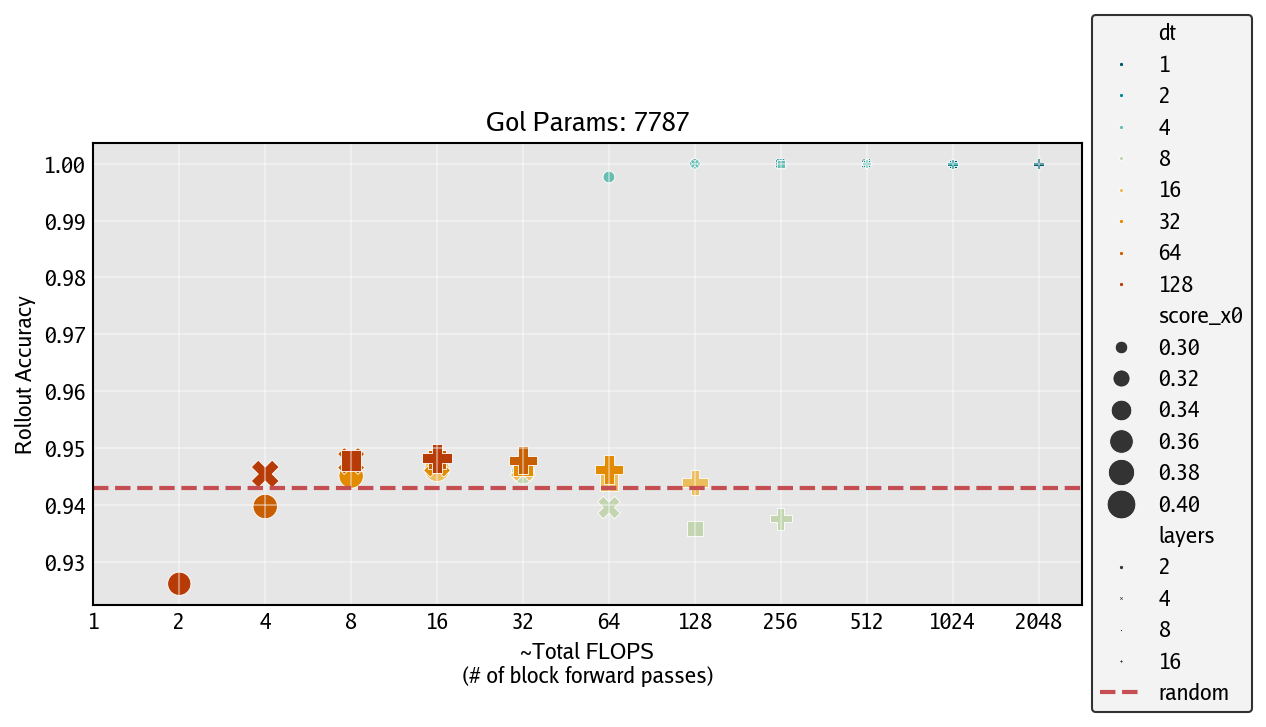

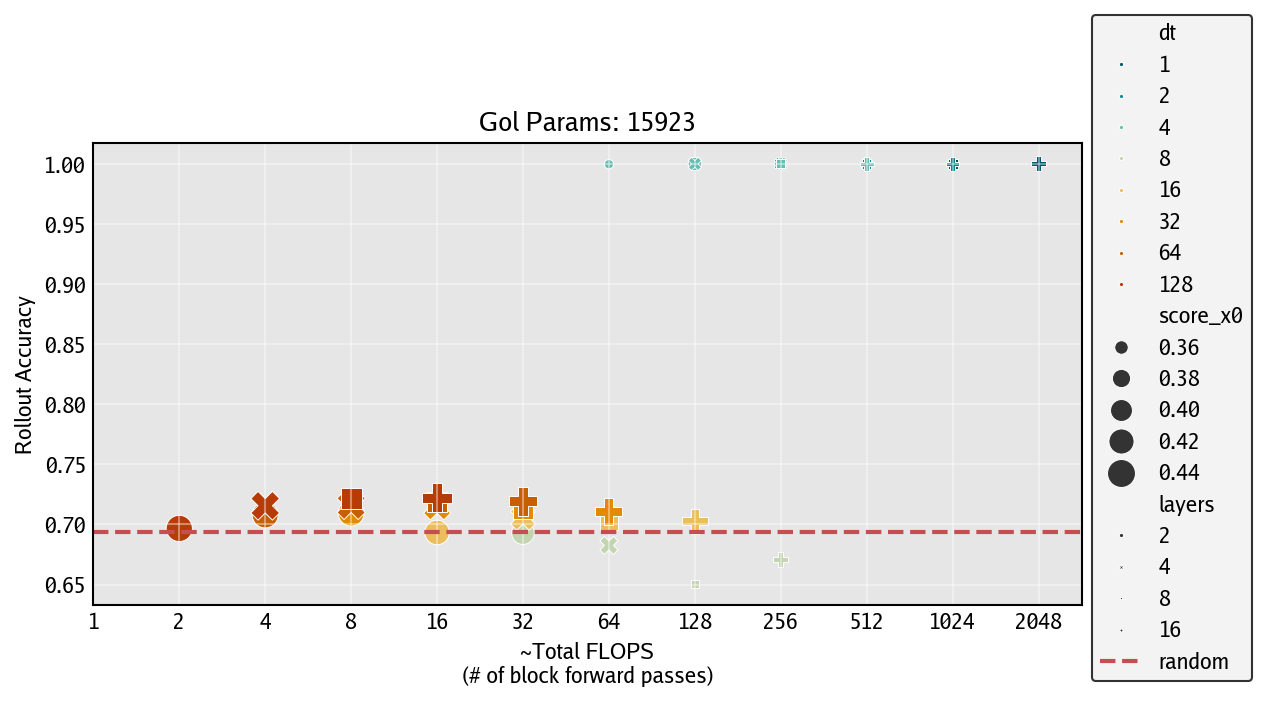

In [49]:
for gol_params in gol_params_all:
    dfa = df[df.gol_params==str(gol_params)].copy()
    sns.scatterplot(data=dfa, x='total_flops', y='rollout_accuracy', hue='dt', style='layers', palette='ak0', size='score_x0', sizes=(20, 200))
    plt.xscale('log')
    # plt.axhline(1-batch['x1'].mean(), color='r', linestyle='--', label='random')
    batch = gol_params2batch[gol_params]
    p = batch['x1'].mean(axis=(-1, -2))
    p = np.maximum(p, 1-p).mean()
    plt.axhline(p, color='r', linestyle='--', label='random')

    plt.legend(bbox_to_anchor=(1, 1.3))
    plt.ylabel("Rollout Accuracy")
    plt.xlabel("~Total FLOPS\n(# of block forward passes)")
    plt.title(f"Gol Params: {gol_params}")
    plt.xticks(2**np.arange(0, 12), 2**np.arange(0, 12))
    plt.grid(True, alpha=0.4)
    plt.show()

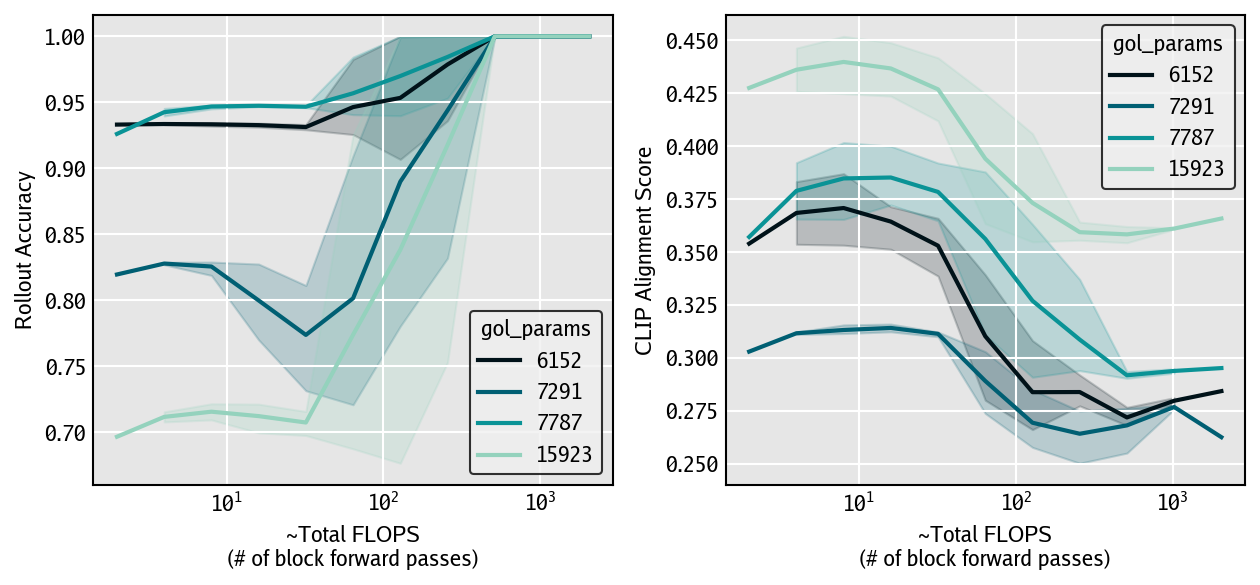

In [63]:
plt.subplot(121)
sns.lineplot(data=df, x="total_flops", y="rollout_accuracy", hue='gol_params')
plt.ylabel("Rollout Accuracy"); plt.xlabel("~Total FLOPS\n(# of block forward passes)")
plt.xscale('log')
plt.subplot(122)
sns.lineplot(data=df, x="total_flops", y="score_x0", hue='gol_params')
plt.ylabel("CLIP Alignment Score"); plt.xlabel("~Total FLOPS\n(# of block forward passes)")
plt.xscale('log')
plt.tight_layout()
plt.show()

In [242]:
rollout_accuracies = []
for args in tqdm(args_all[32:64]):
    main = Main(args)
    params = util.load_pkl(args.save_dir, "params")
    rollout_accuracy = calc_rollout_accuracy(main, params, batch)
    rollout_accuracies.append(rollout_accuracy)

  0%|          | 0/32 [00:00<?, ?it/s]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_7/gol_params=7291_dt=1_layers=2_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=2, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[1]))


  3%|▎         | 1/32 [00:02<01:08,  2.21s/it]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_7/gol_params=7291_dt=1_layers=4_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=4, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[1]))


  6%|▋         | 2/32 [00:07<01:55,  3.84s/it]

...

 94%|█████████▍| 30/32 [01:30<00:01,  1.15it/s]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_7/gol_params=7291_dt=128_layers=8_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=8, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[128]))


 97%|█████████▋| 31/32 [01:31<00:00,  1.19it/s]

Args(seed=0, save_dir='/home/akarsh_sakana_ai/alife-repr-data/run_7/gol_params=7291_dt=128_layers=16_seed=0', n_iters=50000, log_every=10000, model=ModelArgs(layers=16, channels=64, out_channels=2, n_dts=1), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(gol_params=7291, grid_size=64, t_start=32, t_end=64, dt=[128]))


100%|██████████| 32/32 [01:33<00:00,  2.91s/it]


In [ ]:
df = []
for i, args in enumerate(args_all[32:64]):
    layers = args.model.layers
    dt = args.data.dt[0]
    total_flops = (128 // dt) * layers

    final_loss = util.load_pkl(args.save_dir, "final_loss")
    dfi = dict(layers=layers, dt=str(dt), total_flops=total_flops,
               rollout_accuracy=rollout_accuracies[i].item(), final_loss=final_loss)
    df.append(dfi)
df = pd.DataFrame(df)
df

,layers,dt,total_flops,rollout_accuracy,final_loss
0,2,1,256,1.000000,2.728484e-14
1,4,1,512,1.000000,1.913392e-10
2,8,1,1024,1.000000,2.262816e-10
3,16,1,2048,1.000000,9.285820e-11
4,2,2,128,0.999283,9.234223e-08
5,4,2,256,1.000000,2.151784e-08
6,8,2,512,0.999677,1.222537e-07
7,16,2,1024,1.000000,1.900039e-09
8,2,4,64,0.959066,2.730166e-05
9,4,4,128,0.999403,4.573346e-07


Text(0.5, 0, '~Total FLOPS\n(# of block forward passes)')

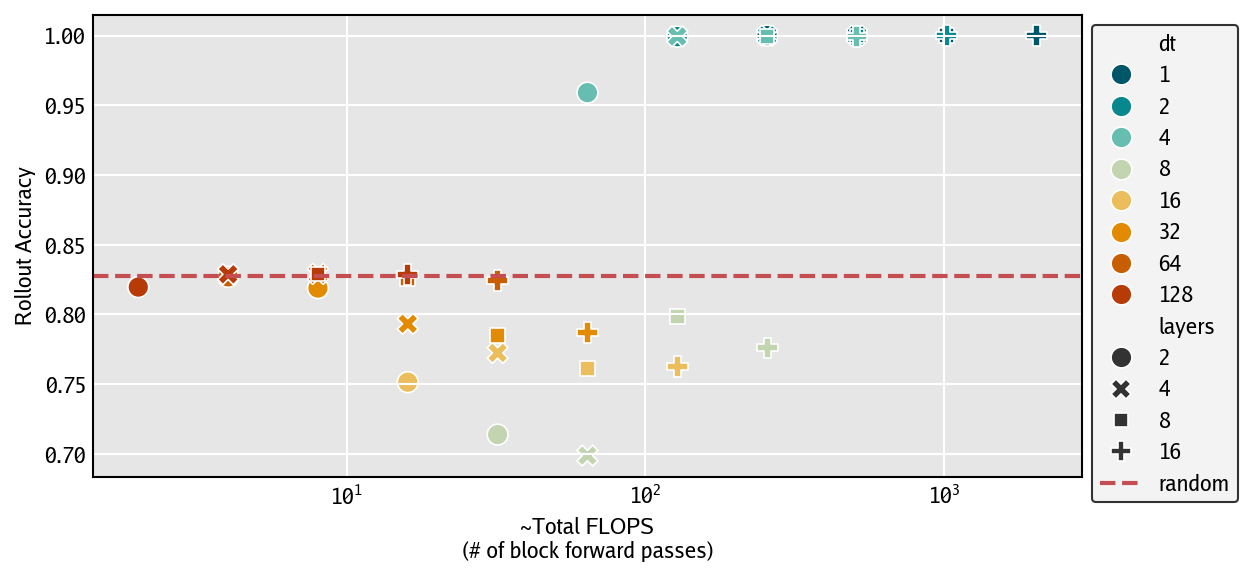

In [262]:
sns.scatterplot(data=df, x='total_flops', y='rollout_accuracy', hue='dt', style='layers', palette='ak0', s=100)
plt.xscale('log')
# plt.axhline(1-batch['x1'].mean(), color='r', linestyle='--', label='random')
p = batch['x1'].mean(axis=(-1, -2))
p = np.maximum(p, 1-p).mean()
plt.axhline(p, color='r', linestyle='--', label='random')

plt.legend(bbox_to_anchor=(1, 1))
plt.ylabel("Rollout Accuracy")
plt.xlabel("~Total FLOPS\n(# of block forward passes)")

<Axes: xlabel='dt', ylabel='final_loss'>

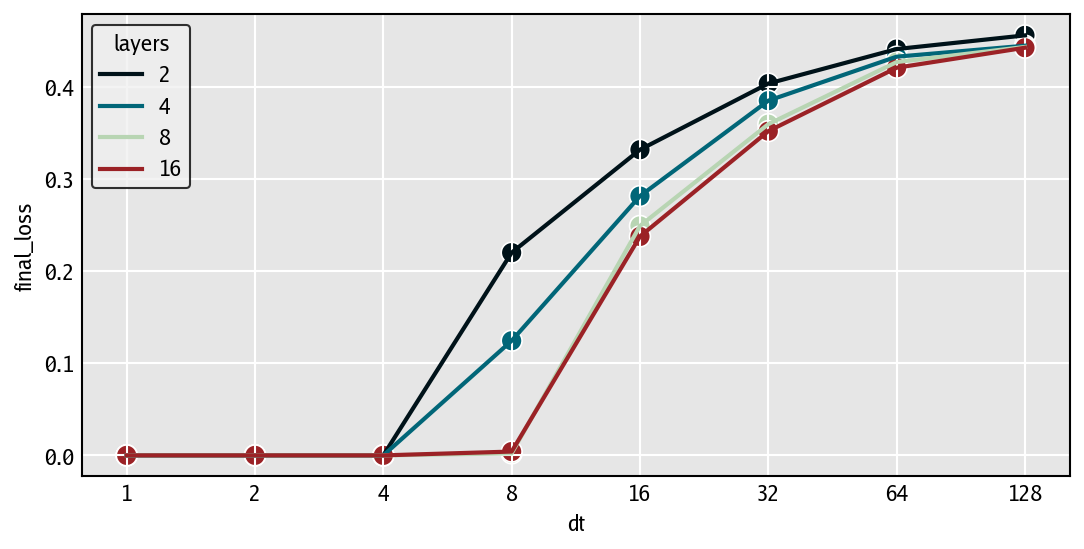

In [263]:
sns.lineplot(data=df, x='dt', y='final_loss', hue='layers', palette='ak0')
sns.scatterplot(data=df, x='dt', y='final_loss', hue='layers', palette='ak0', s=100, legend=False)